## Components of Feature Engineering

Feature engineering is a crucial step in the machine learning pipeline that involves creating new features or transforming existing ones to improve the performance of a model. The components of feature engineering include:

1. **Feature Creation**: This involves generating new features from the existing data. For example, if you have a dataset with a date column, you can create new features such as the day of the week, month, or year.
2. **Feature Transformation**: This involves modifying the scale or distribution of existing features. For example, you can apply logarithmic transformations to reduce skewness or normalize features to a standard scale.
3. **Feature Selection**: This involves choosing the most relevant features for the model. Techniques such as correlation analysis, recursive feature elimination, or feature importance from tree-based models can be used to select the best features.
4. **Feature Encoding**: This involves converting categorical variables into a format that can be used by machine learning algorithms. Techniques such as one-hot encoding, label encoding, or target encoding can be used for this purpose.

# Feature Scaling

Feature scaling is a technique used to standardize the range of independent variables or features of data.

### Standardization (Z-score normalization)
Standardization transforms the data to have a mean of 0 and a standard deviation of 1


In [21]:
import numpy as np
import pandas as pd

In [22]:
# Z-score normalization
np.random.seed(88)

n_students = 100

age = np.random.randint(20,60, n_students)

cgpa = np.random.normal(8, 3 , n_students)
cgpa = np.round(cgpa, 2)
cgpa = np.clip(cgpa, 4.0, 10.0)

placement_prob = (cgpa - 4.0) / 6.0  # Maps 4.0->0.0, 10.0->1.0
placement = (np.random.random(n_students) < placement_prob).astype(int)

df = pd.DataFrame({
    'age': age,
    'cgpa': cgpa,
    'placement': placement})

df['age_scaled'] = (df['age'] - df['age'].mean()) / df['age'].std()
df['cgpa_scaled'] = (df['cgpa'] - df['cgpa'].mean()) / df['cgpa'].std()

pd.reset_option('display.max_rows')
df

,age,cgpa,placement,age_scaled,cgpa_scaled
0,44,9.04,1,0.433300,0.752539
1,52,5.19,0,1.139288,-1.162002
2,35,4.00,0,-0.360936,-1.753770
3,40,8.94,1,0.080306,0.702811
4,57,4.15,0,1.580531,-1.679177
...,...,...,...,...,...
95,29,6.14,0,-0.890428,-0.689583
96,57,6.95,1,1.580531,-0.286783
97,20,4.00,0,-1.684664,-1.753770
98,56,7.41,0,1.492282,-0.058033


In [23]:
X_train = df[['age', 'cgpa']]

X_train_scaled = pd.DataFrame({'age_scaled': df['age_scaled'], 'cgpa_scaled': df['cgpa_scaled']})
np.round(X_train_scaled.describe(), 1)

,age_scaled,cgpa_scaled
count,100.0,100.0
mean,-0.0,0.0
std,1.0,1.0
min,-1.7,-1.8
25%,-0.9,-0.8
50%,-0.0,0.1
75%,0.8,1.0
max,1.8,1.2


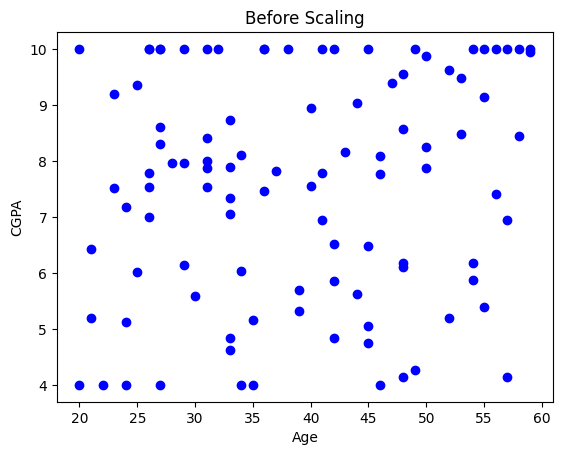

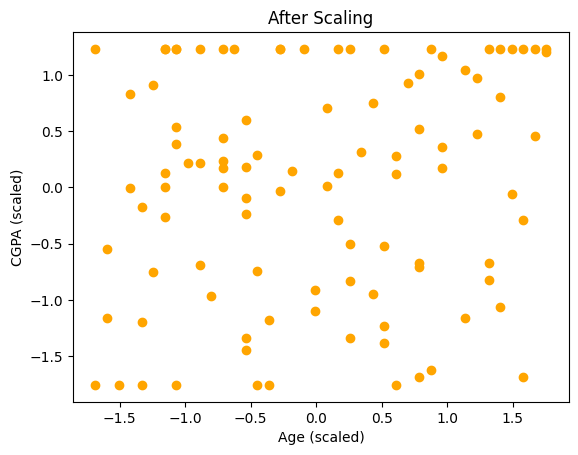

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns 

plt.scatter(x=df['age'], y=df['cgpa'],color='blue')
plt.title('Before Scaling')
plt.xlabel('Age')
plt.ylabel('CGPA')
plt.show()

plt.scatter(x=df['age_scaled'], y=df['cgpa_scaled'] ,color='orange')
plt.title('After Scaling')
plt.xlabel('Age (scaled)')
plt.ylabel('CGPA (scaled)')
plt.show()

C:\Users\biswa\AppData\Local\Temp\ipykernel_24792\4244487466.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=X_train['age'], color='blue', shade=True)
C:\Users\biswa\AppData\Local\Temp\ipykernel_24792\4244487466.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=X_train['cgpa'], color='orange', shade=True)


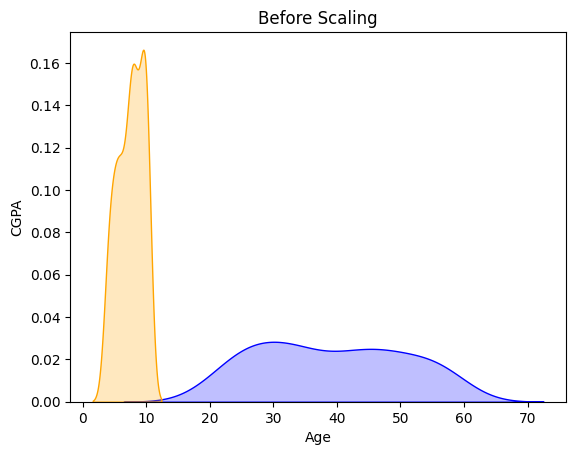

C:\Users\biswa\AppData\Local\Temp\ipykernel_24792\4244487466.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=X_train_scaled['age_scaled'], color='blue', shade=True)
C:\Users\biswa\AppData\Local\Temp\ipykernel_24792\4244487466.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=X_train_scaled['cgpa_scaled'], color='orange', shade=True)


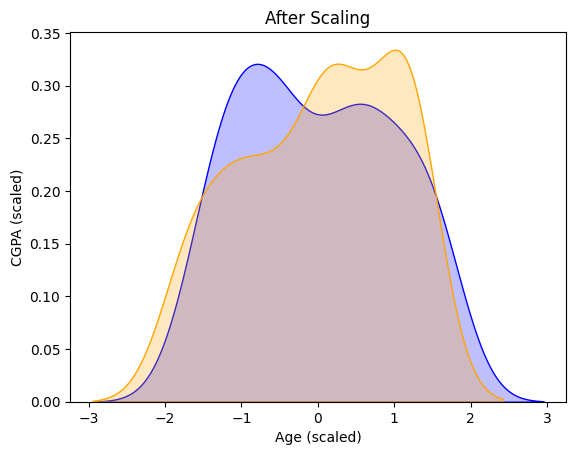

In [25]:
sns.kdeplot(x=X_train['age'], color='blue', shade=True)
sns.kdeplot(x=X_train['cgpa'], color='orange', shade=True)
plt.title('Before Scaling')
plt.xlabel('Age')
plt.ylabel('CGPA')
plt.show()

sns.kdeplot(x=X_train_scaled['age_scaled'], color='blue', shade=True)
sns.kdeplot(x=X_train_scaled['cgpa_scaled'], color='orange', shade=True)
plt.title('After Scaling')
plt.xlabel('Age (scaled)')
plt.ylabel('CGPA (scaled)')
plt.show()

### Algorithms that are sensitive to Standardization:

- K-Nearest Neighbors (KNN)
- Support Vector Machines (SVM)
- Kmeans Clustering
- Principal Component Analysis (PCA)
- Logistic Regression
- Artificial Neural Networks (ANN)
- Gradient Descent based algorithms

### Normalization (Min-Max Scaling)
Normalization scales the data to a fixed range, usually 0 to 1.

#### Min-Max Scaling 

In [26]:
import sklearn.datasets as datasets
from sklearn.preprocessing import StandardScaler, MinMaxScaler

wine = datasets.load_wine()
wine_df = pd.DataFrame(wine.data, columns=wine.feature_names)
wine_df['target'] = wine.target
wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [27]:
wine = wine_df[['alcohol', 'malic_acid', 'ash', 'magnesium','target']]
wine

,alcohol,malic_acid,ash,magnesium,target
0,14.23,1.71,2.43,127.0,0
1,13.20,1.78,2.14,100.0,0
2,13.16,2.36,2.67,101.0,0
3,14.37,1.95,2.50,113.0,0
4,13.24,2.59,2.87,118.0,0
...,...,...,...,...,...
173,13.71,5.65,2.45,95.0,2
174,13.40,3.91,2.48,102.0,2
175,13.27,4.28,2.26,120.0,2
176,13.17,2.59,2.37,120.0,2


In [28]:
from sklearn.model_selection import train_test_split

X = wine[['alcohol', 'malic_acid', 'ash', 'magnesium']]
y = wine['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=88)

In [29]:
# Min-Max Scaling
scalar = MinMaxScaler()

scalar.fit(X_train)

X_train_scaled = scalar.transform(X_train)
X_test_scaled = scalar.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)


In [30]:
np.round(X_train_scaled.describe(), decimals=1)

,alcohol,malic_acid,ash,magnesium
count,142.0,142.0,142.0,142.0
mean,0.5,0.3,0.5,0.3
std,0.2,0.2,0.2,0.2
min,0.0,0.0,0.0,0.0
25%,0.4,0.1,0.5,0.2
50%,0.5,0.2,0.5,0.3
75%,0.7,0.5,0.6,0.4
max,1.0,1.0,1.0,1.0


C:\Users\biswa\AppData\Local\Temp\ipykernel_24792\793378467.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=X_train['alcohol'], color='blue', shade=True)
C:\Users\biswa\AppData\Local\Temp\ipykernel_24792\793378467.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=X_train['malic_acid'], color='orange', shade=True)


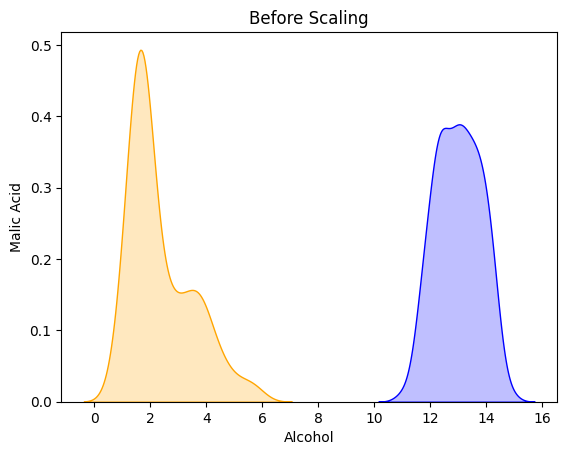

C:\Users\biswa\AppData\Local\Temp\ipykernel_24792\793378467.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=X_train_scaled['alcohol'], color='blue', shade=True)
C:\Users\biswa\AppData\Local\Temp\ipykernel_24792\793378467.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=X_train_scaled['malic_acid'], color='orange', shade=True)


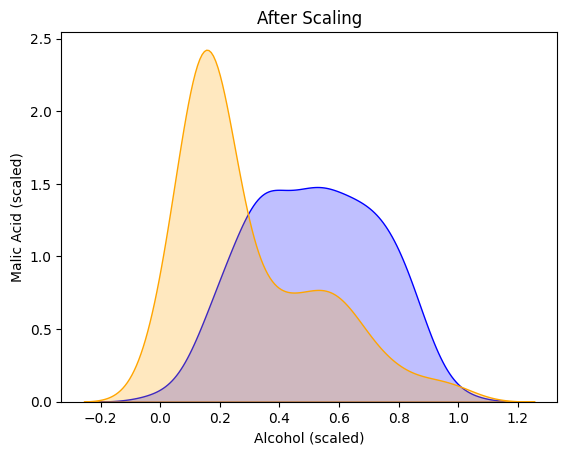

In [31]:
sns.kdeplot(x=X_train['alcohol'], color='blue', shade=True)
sns.kdeplot(x=X_train['malic_acid'], color='orange', shade=True)
plt.title('Before Scaling')
plt.xlabel('Alcohol')
plt.ylabel('Malic Acid')
plt.show()

sns.kdeplot(x=X_train_scaled['alcohol'], color='blue', shade=True)
sns.kdeplot(x=X_train_scaled['malic_acid'], color='orange', shade=True)
plt.title('After Scaling')  
plt.xlabel('Alcohol (scaled)')
plt.ylabel('Malic Acid (scaled)')
plt.show()

#### Mean Normalization

**X_mean_norm = (X - X.mean()) / (X.max() - X.min())**

#### Max Abs Scaling
**X_max_abs_scaled = X / X.abs().max()**

#### Robust Scaling
Robust Scaling uses the median and the interquartile range for scaling, making it robust to outliers.

**X_robust_scaled = (X - X.median()) / (X.quantile(0.75) - X.quantile(0.25))**

It is Robust to outliers because it uses the median and interquartile range instead of mean and standard deviation, which can be heavily influenced by outliers.

### Encoding Categorical Data
Categorical data can be encoded using various techniques such as:

#### Ordinal Encoding

Ordinal encoding assigns a unique integer to each category in a feature. This method is suitable for ordinal data where the categories have a **meaningful order.** 
For example, if you have a feature "Education Level" with categories "High School", "Bachelor's", "Master's", and "PhD", you can encode them as 0, 1, 2, and 3 respectively.

In [32]:
import numpy as np
import pandas as pd

np.random.seed(88)

score = np.random.randint(0, 101, 100)

category = ['A' , 'B' , 'C']
categories = np.random.choice(category, 100)

df = pd.DataFrame({'score': score, 'category': categories})

grade = np.where(categories == 'A' , 2 , np.where(categories == 'B', 1, np.where(categories == 'C', 0, 0)))

df_with_ordinal = pd.DataFrame({'score': score, 'category': categories, 'grade': grade})
df_with_ordinal.head()

,score,category,grade
0,88,A,2
1,32,B,1
2,79,C,0
3,49,C,0
4,20,B,1


In [33]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[['C', 'B', 'A']])
oe.fit(df[['category']])

df['category_encoded'] = oe.transform(df[['category']])
df.head()

,score,category,category_encoded
0,88,A,2.0
1,32,B,1.0
2,79,C,0.0
3,49,C,0.0
4,20,B,1.0


#### One-Hot Encoding
One-hot encoding creates binary columns for each category in a feature. This method is suitable for nominal data where the categories do not have a meaningful order. For example, if you have a feature "Color" with categories "Red", "Green", and "Blue", one-hot encoding would create three binary columns: "Color_Red", "Color_Green", and "Color_Blue".

In [34]:
#### One-Hot Encoding

target = np.random.randint(0,2,100)

color = ['Red', 'Green', 'Blue']
colors = np.random.choice(color, 100)

df_colors = pd.DataFrame({'color': colors, 'target': target})
df_colors.head()

,color,target
0,Green,0
1,Green,0
2,Red,1
3,Blue,0
4,Blue,0


In [35]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(categories=[['Blue', 'Green', 'Red']], drop='first')
encoded = ohe.fit_transform(df_colors[['color']]).toarray()
df_colors_encoded = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(['color']))
df_colors_encoded.head()

,color_Green,color_Red
0,1.0,0.0
1,1.0,0.0
2,0.0,1.0
3,0.0,0.0
4,0.0,0.0


In [36]:
print(ohe.get_feature_names_out(['color']))

['color_Green' 'color_Red']


#### Column transformer
ColumnTransformer allows you to apply different transformations to different columns in your dataset. 

In [37]:
# Improved toy dataset: Cough and has_covid as categorical, Fever in Fahrenheit
import numpy as np
import pandas as pd

np.random.seed(42)
n = 100

ages = np.random.randint(18, 70, n)
genders = np.random.choice(['Male', 'Female'], n)
# Fever in Fahrenheit (simulate normal and feverish values)
fever = np.random.normal(loc=98.6, scale=2.5, size=n)
# Cough as categorical
cough = np.random.choice(['Yes', 'No'], n)
cities = np.random.choice(['Delhi', 'Mumbai', 'Bangalore', 'Chennai'], n)
# has_covid as categorical
has_covid = np.random.choice(['Yes', 'No'], n)

df_toy = pd.DataFrame({
    'Age': ages,
    'Gender': genders,
    'Fever_F': np.round(fever, 1),
    'Cough': cough,
    'City': cities,
    'has_covid': has_covid
})

# Introduce up to 10 random missing values
for _ in range(np.random.randint(5, 11)):
    row = np.random.randint(0, n)
    col = np.random.choice(df_toy.columns)
    df_toy.loc[row, col] = np.nan

df_toy.head(10)
df_toy.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        98 non-null     float64
 1   Gender     99 non-null     str    
 2   Fever_F    98 non-null     float64
 3   Cough      100 non-null    str    
 4   City       98 non-null     str    
 5   has_covid  99 non-null     str    
dtypes: float64(2), str(4)
memory usage: 4.8 KB


In [38]:
df_toy['Cough'].value_counts()

Cough
No     53
Yes    47
Name: count, dtype: int64

In [39]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(df_toy.drop('has_covid', axis=1), df_toy['has_covid'], test_size=0.2, random_state=42)

In [40]:
X_train

,Age,Gender,Fever_F,Cough,City
55,37.0,Male,98.8,Yes,Delhi
88,38.0,Female,95.3,No,Mumbai
26,29.0,Male,101.7,No,Bangalore
42,68.0,Male,98.7,No,Mumbai
69,19.0,Female,99.8,Yes,Mumbai
...,...,...,...,...,...
60,25.0,Female,96.0,No,Chennai
71,59.0,Female,101.3,Yes,Chennai
14,57.0,Female,96.9,No,Bangalore
92,64.0,Female,100.9,Yes,Mumbai


In [59]:
### Doing without ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

## Handling missing values in Fever_F , Gender , Age , City , has_covid
si = SimpleImputer()
X_train_fever = si.fit_transform(X_train[['Fever_F']])
X_test_fever = si.transform(X_test[['Fever_F']])

X_train_age = si.fit_transform(X_train[['Age']])
X_test_age = si.transform(X_test[['Age']])

X_train_Gender = X_train['Gender'].fillna(X_train['Gender'].mode()[0], inplace=True)
X_test_Gender = X_test['Gender'].fillna(X_test['Gender'].mode()[0], inplace=True)

X_train_City = X_train['City'].fillna(X_train['City'].mode()[0], inplace=True)
X_test_City = X_test['City'].fillna(X_test['City'].mode()[0], inplace=True)

## Ordinal Encoding for Cough
oe = OrdinalEncoder(categories=[['No' , 'Yes']])
X_train_cough = oe.fit_transform(X_train[['Cough']])
X_test_cough = oe.transform(X_test[['Cough']])

## One-Hot Encoding for City and gender
ohe_city = OneHotEncoder(drop='first')
X_train_City = ohe_city.fit_transform(X_train_City.values.reshape(-1, 1)).toarray()
X_test_City = ohe_city.transform(X_test_City.values.reshape(-1, 1)).toarray()

ohe_gender = OneHotEncoder(drop='first')
X_train_Gender_ohe = ohe_gender.fit_transform(X_train_Gender.values.reshape(-1, 1)).toarray()
X_test_Gender_ohe = ohe_gender.transform(X_test_Gender.values.reshape(-1, 1)).toarray()

X_train_final = np.hstack((X_train_fever, X_train_age, X_train_cough, X_train_City, X_train_Gender_ohe))
X_test_final = np.hstack((X_test_fever, X_test_age, X_test_cough, X_test_City, X_test_Gender_ohe))

NameError: name 'X_train' is not defined

In [42]:
df_train = pd.DataFrame(X_train_final)
df_train.head()

,0,1,2,3,4,5,6
0,98.8,37.0,1.0,0.0,1.0,0.0,1.0
1,95.3,38.0,0.0,0.0,0.0,1.0,0.0
2,101.7,29.0,0.0,0.0,0.0,0.0,1.0
3,98.7,68.0,0.0,0.0,0.0,1.0,1.0
4,99.8,19.0,1.0,0.0,0.0,1.0,0.0


In [43]:
### Using ColumnTransformer
from sklearn.compose import ColumnTransformer

transformer = ColumnTransformer(
    transformers=[
        ('tnf1', SimpleImputer(), ['Fever_F', 'Age']),
        #('tnf2', SimpleImputer(), ['Gender' , 'Cough' , 'City']),
        ('tnf4', OrdinalEncoder(categories=[['No' , 'Yes']]), ['Cough']),
        ('tnf5', OneHotEncoder(drop='first'), ['City','Gender']),
    ],
    remainder='passthrough')

In [44]:
pd.DataFrame(transformer.fit_transform(X_train))

,0,1,2,3,4,5,6,7,8
0,98.8,37.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,95.3,38.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,101.7,29.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,98.7,68.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,99.8,19.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
75,96.0,25.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
76,101.3,59.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
77,96.9,57.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
78,100.9,64.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [45]:
X_train_final.shape

(80, 7)

In [46]:
# Get feature names for the transformed DataFrame
import numpy as np
from itertools import chain

# Fit the transformer
transformer.fit(X_train)

# Get feature names for each transformer
num_features = ['Fever_F', 'Age']
cough_feature = ['Cough']
city_gender_features = transformer.named_transformers_['tnf5'].get_feature_names_out(['City', 'Gender'])

# Combine all feature names
all_feature_names = list(num_features) + cough_feature + list(city_gender_features)

# Transform the data
X_train_transformed = transformer.transform(X_train)

# Create DataFrame with correct column names
df_transformed = pd.DataFrame(X_train_transformed, columns=all_feature_names)
df_transformed.head()

,Fever_F,Age,Cough,City_Chennai,City_Delhi,City_Mumbai,City_nan,Gender_Male,Gender_nan
0,98.8,37.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,95.3,38.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,101.7,29.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,98.7,68.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,99.8,19.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


# Mathematical Transformations

## Log Transformation

#### Log transformation

Log transformation is a mathematical technique used to transform skewed data into a more normal distribution. It is particularly useful when dealing with data that has a long tail or is heavily skewed. The log transformation can help stabilize the variance and make the data more suitable for modeling.

#### How to Find if data is Normally Distributed?

1. **Histogram with KDE**: `sns.distplot(data['feature'], kde=True)`
2. **Q-Q Plot**: `sm.qqplot(data['feature'], line='s')`
3. pd.skew(data['feature']) and pd.kurtosis(data['feature'])


In [47]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler , FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer 

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [48]:
df = pd.read_csv('mlFolder/datasets/Titanic-Dataset.csv' , usecols=['Age', 'Fare', 'Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


In [50]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [51]:
df['Age'] = df['Age'].fillna(df['Age'].mean(), inplace=True)
df.isnull().sum()

C:\Users\biswa\AppData\Local\Temp\ipykernel_24792\3442923519.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'] = df['Age'].fillna(df['Age'].mean(), inplace=True)


Survived    0
Age         0
Fare        0
dtype: int64

In [52]:
X = df.iloc[:, 1:3]
y = df.iloc[:, 0]
print(X.head() )
print(y.head() )  

    Age     Fare
0  22.0   7.2500
1  38.0  71.2833
2  26.0   7.9250
3  35.0  53.1000
4  35.0   8.0500
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


Text(0.5, 1.0, 'Q-Q Plot for Age_log')

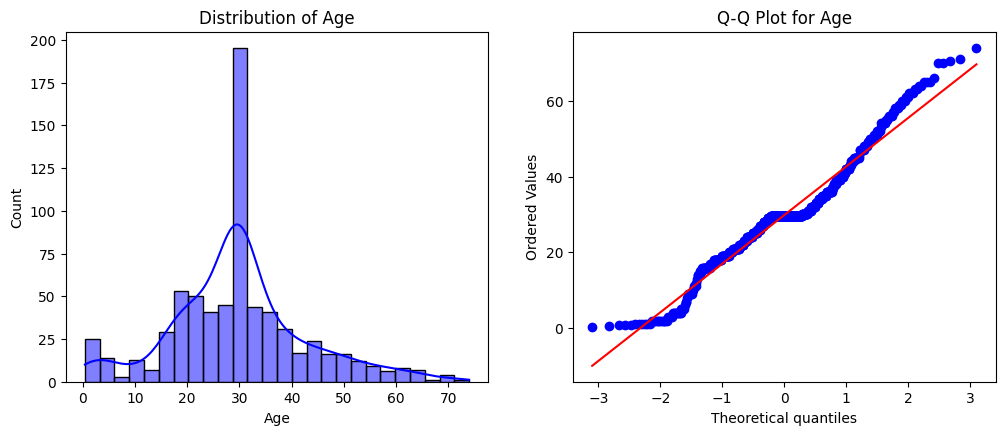

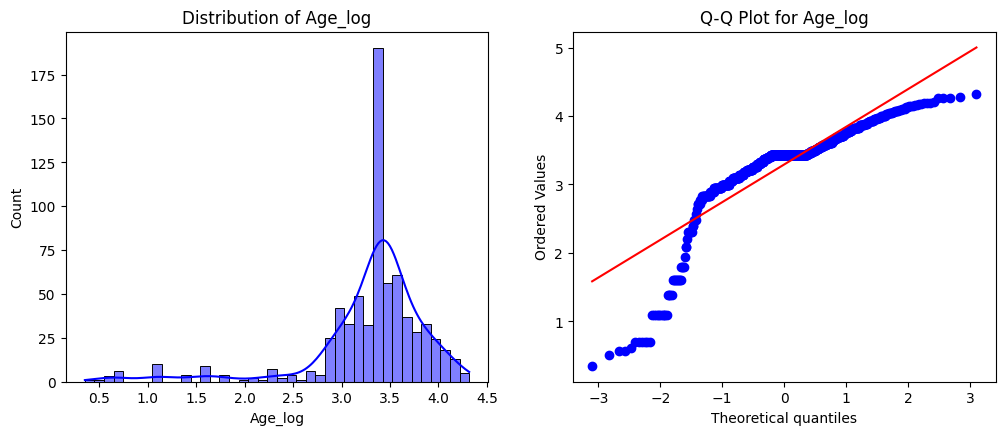

In [53]:
### Now will plot the QQ plot for Age and Fare to check the normality of the data. If the data is not normally distributed then we will apply log transformation to make it normally distributed.
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(88)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=88)

plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
sns.histplot(X_train['Age'], kde=True, color='blue')
plt.title('Distribution of Age')

plt.subplot(2, 2, 2)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Q-Q Plot for Age')

## Log transformation for Age
tnf1 = FunctionTransformer(func=np.log1p)
X_train['Age_log'] = tnf1.fit_transform(X_train[['Age']])

plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 3)
sns.histplot(X_train['Age_log'], kde=True, color='blue')
plt.title('Distribution of Age_log')

plt.subplot(2, 2, 4)
stats.probplot(X_train['Age_log'], dist="norm", plot=plt)
plt.title('Q-Q Plot for Age_log')

Text(0.5, 1.0, 'Q-Q Plot for Fare_log')

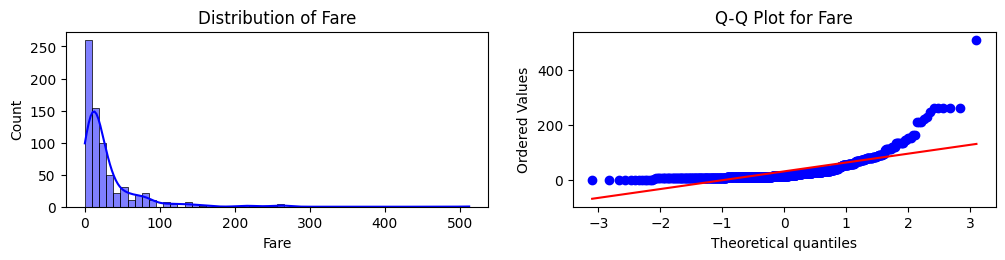

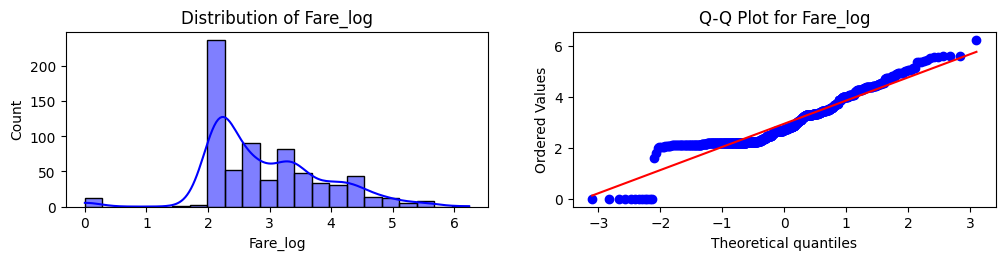

In [54]:
### Now will plot the QQ plot for Fare to check the normality of the data. If the data is not normally distributed then we will apply log transformation to make it normally distributed.
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(88)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=88)

plt.figure(figsize=(12, 5))
plt.subplot(2, 2, 1)
sns.histplot(X_train['Fare'], kde=True, color='blue')
plt.title('Distribution of Fare')

plt.subplot(2, 2, 2)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Q-Q Plot for Fare')

## Log transformation for Fare
tnf1 = FunctionTransformer(func=np.log1p)
X_train['Fare_log'] = tnf1.fit_transform(X_train[['Fare']])

plt.figure(figsize=(12, 5))
plt.subplot(2, 2, 3)
sns.histplot(X_train['Fare_log'], kde=True, color='blue')
plt.title('Distribution of Fare_log')

plt.subplot(2, 2, 4)
stats.probplot(X_train['Fare_log'], dist="norm", plot=plt)
plt.title('Q-Q Plot for Fare_log')

In [55]:
from sklearn.model_selection import cross_val_score 

def apply_transformation(param_X):

    trf = ColumnTransformer(
        transformers=[
            ('tnf1' , FunctionTransformer(param_X) , ['Fare'])
        ], remainder='passthrough'
    )

    X_train_trf = trf.fit_transform(X_train)

    clf = LogisticRegression()

    print('Accuracy' , np.mean(cross_val_score(clf, X_train_trf, y_train, cv=10)))

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 2)
    stats.probplot(np.array(X_train_trf).flatten(), dist="norm", plot=plt)
    plt.title('Q-Q Plot for Fare after transformation')

    plt.subplot(1, 2, 1)
    stats.probplot(np.array(X_train['Fare']).flatten(), dist="norm", plot=plt)
    plt.title('Q-Q Plot for Fare before transformation')

    plt.show()

Accuracy 0.675586854460094


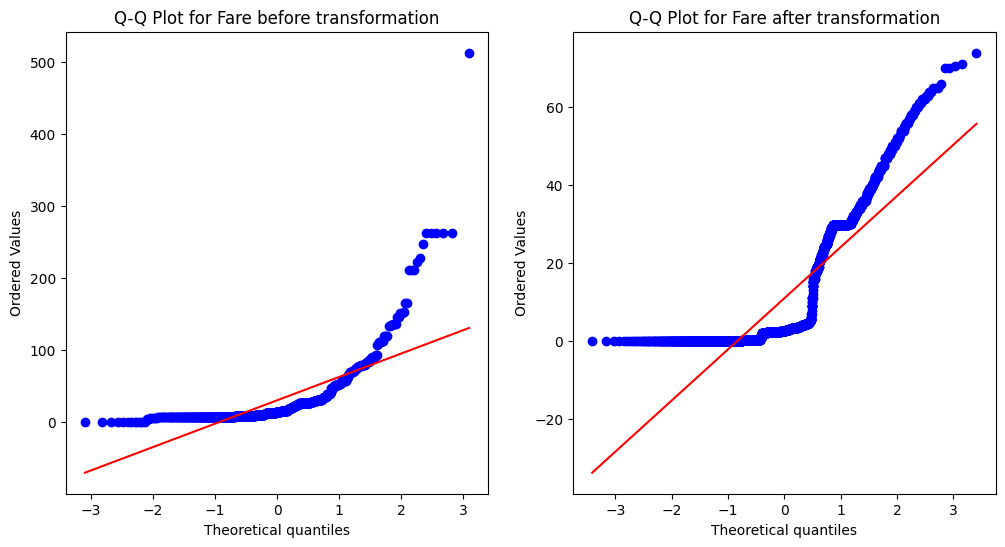

In [60]:
apply_transformation(lambda x: 1/(x + 1))

## Box-Cox Transformation

Box cox transformation is a family of power transformations that can be used to stabilize variance and make the data more normal. It is defined as:

$$\begin{array}{|c|c|} \hline
\lambda & \text{Transformation} \\ \hline
\lambda \neq 0 & y(\lambda) = \frac{y^{\lambda} - 1}{\lambda} \\ \hline
\lambda = 0 & y(\lambda) = \log(y) \\ \hline
\end{array}$$

The exponent here is a variable called lambda that varies over the range of -5 to 5. The optimal value of lambda can be found using maximum likelihood estimation.Finally we choose the optimal value (resulting in the best approximation to normality) for your variable and apply the transformation to your data.


$$
\begin{array}{|l|l|l|}
\hline
\textbf{Restriction} & \textbf{Description} & \textbf{Alternative} \\ \hline
\text{Data Sign} & \text{Must be strictly positive } (x > 0). & \text{Use Yeo-Johnson.} \\ \hline
\text{Outliers} & \text{Can distort the optimal } \lambda. & \text{Use RobustScaler or clip outliers.} \\ \hline
\text{Interpretability} & \text{Transformed units lack physical meaning.} & \text{Use Log transform (easier to explain).} \\ \hline
\text{Distribution} & \text{Only works for unimodal skewed data.} & \text{Use QuantileTransformer.} \\ \hline
\end{array}
$$

## Yeo-Johnson Transformation

This transformation is somewhat of an adjustment to the Box-Cox transformation that can handle both positive and negative values.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats
from sklearn.preprocessing import FunctionTransformer , PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

In [3]:
df = pd.read_csv('./datasets/concrete_data.csv')
df.head()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [4]:
df.shape

(1030, 9)

In [5]:
df.isnull().sum()

cement                           0
blast_furnace_slag               0
fly_ash                          0
water                            0
superplasticizer                 0
coarse_aggregate                 0
fine_aggregate                   0
age                              0
concrete_compressive_strength    0
dtype: int64

In [6]:
df.describe()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [8]:
X = df.drop('concrete_compressive_strength', axis=1)
y = df['concrete_compressive_strength']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=88)

In [10]:
# Applying Linear Regression without any transformation
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

r2_score(y_test, y_pred)

0.6445249177004909

In [13]:
np.mean(cross_val_score(lr , X=X_train , y=y_train , scoring='r2'))

np.float64(0.5932321522346016)

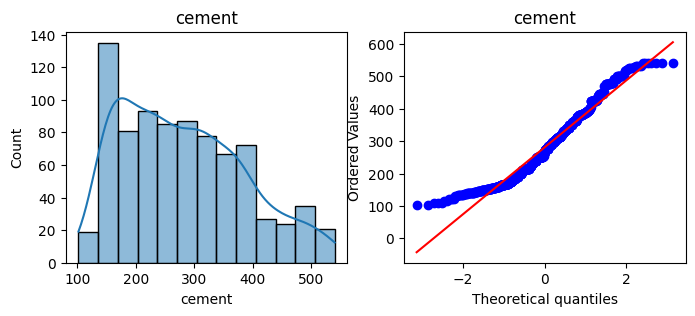

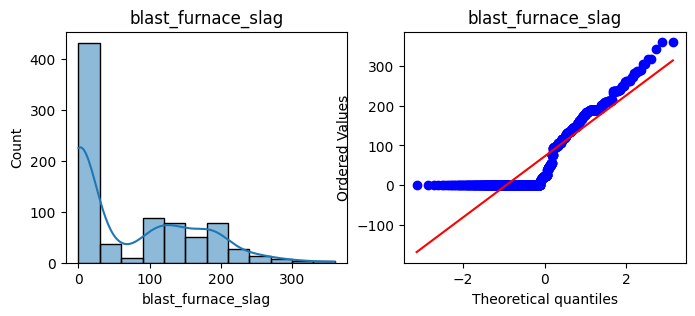

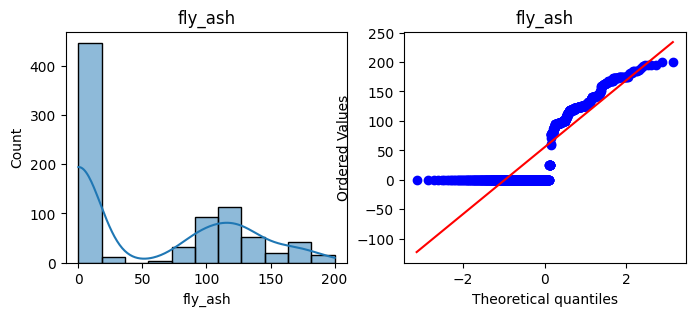

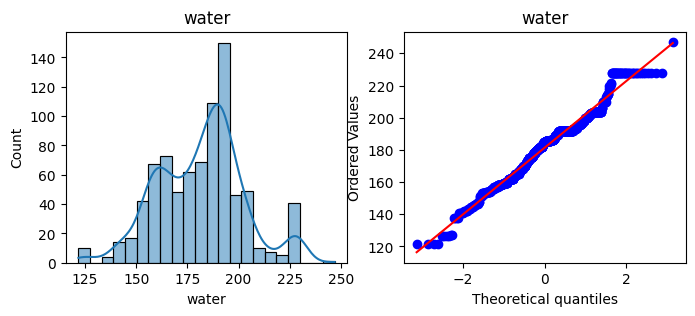

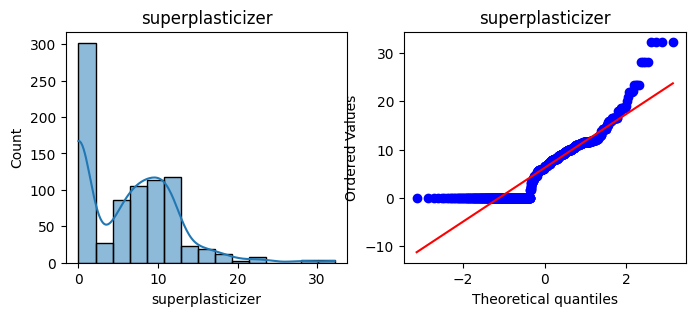

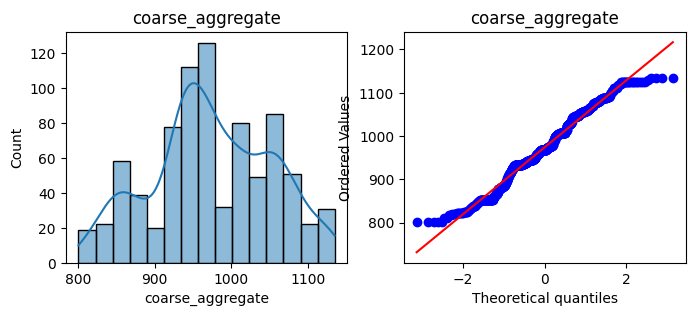

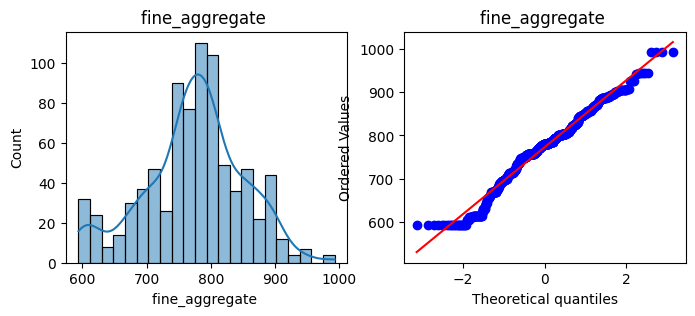

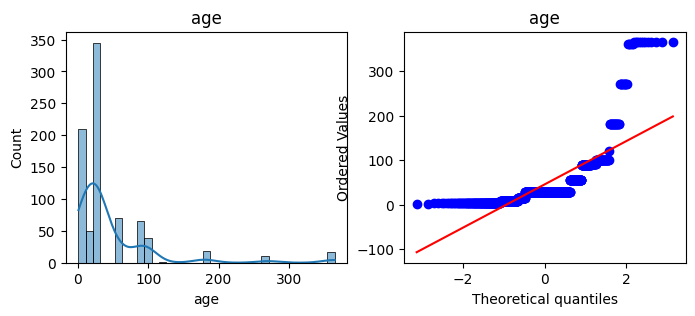

In [19]:
for col in X_train.columns:
    plt.figure(figsize=(8,3))
    plt.subplot(1,2,1)
    sns.histplot(x=X_train[col],kde=True)
    plt.title(col)

    plt.subplot(1,2,2)
    stats.probplot(x=X_train[col] , dist='norm' , plot=plt)
    plt.title(col)

In [23]:
pt = PowerTransformer()

X_train_transformed = pt.fit_transform(X_train)

lr = LinearRegression()
np.mean(cross_val_score(lr , X_train_transformed , y_train, scoring='r2'))

np.float64(0.7967401703455285)

In [28]:
# Getting all the lamdas

pt = PowerTransformer(method='yeo-johnson')

X_train_transformed = pt.fit_transform(X_train)
X_test_transformed = pt.transform(X_test)

lr.fit(X_train_transformed , y_train)

y_pred = lr.predict(X_test_transformed)

print(r2_score(y_test , y_pred))

pd.DataFrame({'cols':X_train.columns , 'Lambdas': pt.lambdas_})

0.8056983914044696


,cols,Lambdas
0,cement,0.124497
1,blast_furnace_slag,0.018029
2,fly_ash,-0.118586
3,water,0.922520
4,superplasticizer,0.279893
5,coarse_aggregate,1.176386
6,fine_aggregate,1.876669
7,age,0.003483


In [27]:
X_train.columns

Index(['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer',
       'coarse_aggregate', 'fine_aggregate ', 'age'],
      dtype='str')

# Handling Mixed Data Types

When dealing with datasets that contain a mix of numerical and categorical features, it is important to apply appropriate transformations to each type of feature. For numerical features, you can apply scaling techniques such as standardization or normalization. For categorical features, you can use encoding techniques such as one-hot encoding or ordinal encoding.

In [67]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
# Create lists to store data
cabin = []
tickets = []
numbers = []
survived = []

# List of possible cabin types and tickets
cabin_types = ['A', 'B', 'C', 'D', 'E']
ticket_numbers = [0, 1, 2, 3, 4]
safety_classes = ['S', 'C']

np.random.seed(10)

# Generate data for 100 rows
for i in range(100):
    cabin.append(np.random.choice(cabin_types) + '/' + str(np.random.randint(1000, 9999)))
    ticket_numbers_str = [f"{np.random.choice(ticket_numbers)}" for _ in range(np.random.randint(1, 3))]
    tickets.append(' '.join(ticket_numbers_str))
    numbers.append(np.random.choice([0, 1, 2, 3, 4, 5, 6, 7, 8, 9 , 'A']))
    survived.append(np.random.choice([0, 1]))

# Create DataFrame
df = pd.DataFrame({
    'cabin': cabin,
    'tickets': tickets,
    'numbers': numbers,
    'survived': survived
})

print(df.head(100))


     cabin tickets numbers  survived
0   B/8293       0       1         1
1   E/5829       1       A         0
2   B/7400       0       6         0
3   D/6648       3       6         0
4   D/8290       1       8         0
..     ...     ...     ...       ...
95  B/5010       0       6         0
96  E/8127       2       6         0
97  B/4507     1 2       A         0
98  A/3982       2       1         0
99  C/4400       3       8         0

[100 rows x 4 columns]


In [25]:
# extract numerical part from numbers column

df['number_numerical'] = pd.to_numeric(df['numbers'], errors='coerce')
df.head()

,cabin,tickets,numbers,survived,number_numerical
0,B/8293,0,1,1,1.0
1,E/5829,1,A,0,NaN
2,B/7400,0,6,0,6.0
3,D/6648,3,6,0,6.0
4,D/8290,1,8,0,8.0


In [26]:
# extract categorical part from numbers column

df['number_categorical'] = np.where(df['number_numerical'].isnull(), df['numbers'], np.nan)
df.head()

,cabin,tickets,numbers,survived,number_numerical,number_categorical
0,B/8293,0,1,1,1.0,NaN
1,E/5829,1,A,0,NaN,A
2,B/7400,0,6,0,6.0,NaN
3,D/6648,3,6,0,6.0,NaN
4,D/8290,1,8,0,8.0,NaN


In [27]:
df['cabin'].unique()

<StringArray>
['B/8293', 'E/5829', 'B/7400', 'D/6648', 'D/8290', 'B/7899', 'B/2828',
 'B/7159', 'A/2681', 'C/1044', 'E/8350', 'C/7768', 'B/9177', 'B/5843',
 'A/1914', 'A/2103', 'A/7929', 'B/9478', 'B/7566', 'D/2106', 'D/3033',
 'B/5776', 'A/8893', 'B/6333', 'E/9743', 'E/8116', 'B/3306', 'C/9845',
 'C/2527', 'C/2458', 'D/3765', 'A/2127', 'E/6390', 'A/8931', 'B/7475',
 'B/3895', 'A/2169', 'E/5285', 'D/7741', 'D/7697', 'B/7845', 'A/8784',
 'A/4808', 'B/2660', 'C/6947', 'C/6831', 'D/8645', 'C/1058', 'A/1144',
 'B/8303', 'A/5416', 'B/2968', 'A/4404', 'D/7062', 'C/2505', 'C/1671',
 'B/8928', 'B/5997', 'D/7624', 'C/6578', 'E/3262', 'D/6797', 'C/5110',
 'C/9321', 'D/1509', 'D/5772', 'D/1059', 'C/6052', 'D/9290', 'B/7132',
 'A/9150', 'C/8504', 'B/4419', 'B/7568', 'D/1503', 'A/4552', 'A/4310',
 'A/5518', 'B/5741', 'B/9192', 'B/6437', 'C/9036', 'A/1522', 'B/2415',
 'B/3962', 'A/6609', 'E/1527', 'E/5810', 'A/4860', 'C/7680', 'D/2375',
 'B/3761', 'C/9581', 'E/1466', 'D/7342', 'B/5010', 'E/8127', 'B

In [33]:
df['cabin_numerical'] = df['cabin'].str.extract('(\d+)')
df['cabin_categorical'] = df['cabin'].str.extract('([A-Za-z])').astype(str)
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\biswa\AppData\Local\Temp\ipykernel_15612\2456051102.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['cabin_numerical'] = df['cabin'].str.extract('(\d+)')


,cabin,tickets,numbers,survived,number_numerical,number_categorical,cabin_numerical,cabin_categorical
0,B/8293,0,1,1,1.0,NaN,8293,B
1,E/5829,1,A,0,NaN,A,5829,E
2,B/7400,0,6,0,6.0,NaN,7400,B
3,D/6648,3,6,0,6.0,NaN,6648,D
4,D/8290,1,8,0,8.0,NaN,8290,D


## Handling Date Time 

In [82]:
import numpy as np
import pandas as pd

In [83]:
df = pd.read_csv('./datasets/orders.csv')
df.head()

,id,order_date,ship_mode,customer_id,sales
0,100006,2014-09-07,Standard,DK-13375,377.970
1,100090,2014-07-08,Standard,EB-13705,699.192
2,100293,2014-03-14,Standard,NF-18475,91.056
3,100328,2014-01-28,Standard,JC-15340,3.928
4,100363,2014-04-08,Standard,JM-15655,21.376


In [84]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5009 entries, 0 to 5008
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           5009 non-null   int64  
 1   order_date   5009 non-null   str    
 2   ship_mode    5009 non-null   str    
 3   customer_id  5009 non-null   str    
 4   sales        5009 non-null   float64
dtypes: float64(1), int64(1), str(3)
memory usage: 195.8 KB


In [85]:
## Changing the date column to datetime format
df['order_date'] = pd.to_datetime(df['order_date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5009 entries, 0 to 5008
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           5009 non-null   int64         
 1   order_date   5009 non-null   datetime64[us]
 2   ship_mode    5009 non-null   str           
 3   customer_id  5009 non-null   str           
 4   sales        5009 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(2)
memory usage: 195.8 KB


In [86]:
df['date_year'] = df['order_date'].dt.year
df['date_month'] = df['order_date'].dt.month
df['date_month_name'] = df['order_date'].dt.month_name()
df['date_day_name'] = df['order_date'].dt.day_name()
df.head()

,id,order_date,ship_mode,customer_id,sales,date_year,date_month,date_month_name,date_day_name
0,100006,2014-09-07,Standard,DK-13375,377.970,2014,9,September,Sunday
1,100090,2014-07-08,Standard,EB-13705,699.192,2014,7,July,Tuesday
2,100293,2014-03-14,Standard,NF-18475,91.056,2014,3,March,Friday
3,100328,2014-01-28,Standard,JC-15340,3.928,2014,1,January,Tuesday
4,100363,2014-04-08,Standard,JM-15655,21.376,2014,4,April,Tuesday


## Complete case analysis

Assumption For CCA 
1. The data is missing completely at random (MCAR), meaning that the missingness is unrelated to the observed or unobserved data.

Advantages of CCA:
1. Simplicity: CCA is straightforward to implement and does not require complex modeling of the missing data mechanism.
2. Unbiased Estimates: If the MCAR assumption holds, CCA provides unbiased estimates of parameters and relationships in the data.

Disadvantages of CCA:
1. Loss of Data: CCA can lead to a significant loss of data, especially if the missingness is not random, which can reduce the statistical power of the analysis.
2. Bias: If the MCAR assumption does not hold, CCA can introduce bias into the analysis, as the remaining data may not be representative of the original dataset.
3. Reduced Generalizability: The results obtained from CCA may not generalize well to the entire population if the missing data is not random, as the analysis is based on a subset of the original data.

In [87]:
df = pd.read_csv('./datasets/data_science_job.csv')
df.head(10)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0
5,21651,city_176,0.764,NaN,Has relevent experience,Part time course,Graduate,STEM,11.0,NaN,NaN,24.0,1.0
6,28806,city_160,0.920,Male,Has relevent experience,no_enrollment,High School,NaN,5.0,50-99,Funded Startup,24.0,0.0
7,402,city_46,0.762,Male,Has relevent experience,no_enrollment,Graduate,STEM,13.0,<10,Pvt Ltd,18.0,1.0
8,27107,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,7.0,50-99,Pvt Ltd,46.0,1.0
9,699,city_103,0.920,NaN,Has relevent experience,no_enrollment,Graduate,STEM,17.0,10000+,Pvt Ltd,123.0,0.0


In [88]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  str    
 2   city_development_index  18679 non-null  float64
 3   gender                  14650 non-null  str    
 4   relevent_experience     19158 non-null  str    
 5   enrolled_university     18772 non-null  str    
 6   education_level         18698 non-null  str    
 7   major_discipline        16345 non-null  str    
 8   experience              19093 non-null  float64
 9   company_size            13220 non-null  str    
 10  company_type            13018 non-null  str    
 11  training_hours          18392 non-null  float64
 12  target                  19158 non-null  float64
dtypes: float64(4), int64(1), str(8)
memory usage: 1.9 MB


In [89]:
df.isnull().mean() * 100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [90]:
## To apply CCA we need to make sure 2 points:-
## 1. Missing values should be present as MCAR (Missing Completely at Random) and not MAR (Missing at Random) or MNAR (Missing Not at Random)
## 2. The missing value's percentage should be less than 5% of the total data. If the percentage is more than 5% then we should not apply CCA and should go for other imputation techniques like mean, median, mode etc.

# We will apply CCA on these columns

df[['city_development_index' , 'enrolled_university' , 'experience' , 'training_hours']].isnull().mean() * 100

city_development_index    2.500261
enrolled_university       2.014824
experience                0.339284
training_hours            3.998330
dtype: float64

In [91]:
df[['city_development_index' , 'enrolled_university' , 'experience' , 'training_hours']].reset_index(drop=True)

,city_development_index,enrolled_university,experience,training_hours
0,0.920,no_enrollment,20.0,36.0
1,0.776,no_enrollment,15.0,47.0
2,0.624,Full time course,5.0,83.0
3,0.789,NaN,0.0,52.0
4,0.767,no_enrollment,20.0,8.0
...,...,...,...,...
19153,0.878,no_enrollment,14.0,42.0
19154,0.920,no_enrollment,14.0,52.0
19155,0.920,no_enrollment,20.0,44.0
19156,0.802,no_enrollment,0.0,97.0


In [97]:
df_new = df[['city_development_index' , 'enrolled_university' , 'experience' , 'training_hours']].dropna().reset_index(drop=True)
df_new.head()

,city_development_index,enrolled_university,experience,training_hours
0,0.920,no_enrollment,20.0,36.0
1,0.776,no_enrollment,15.0,47.0
2,0.624,Full time course,5.0,83.0
3,0.767,no_enrollment,20.0,8.0
4,0.764,Part time course,11.0,24.0


In [98]:
df.shape , df_new.shape

((19158, 13), (17509, 4))

<Axes: ylabel='Count'>

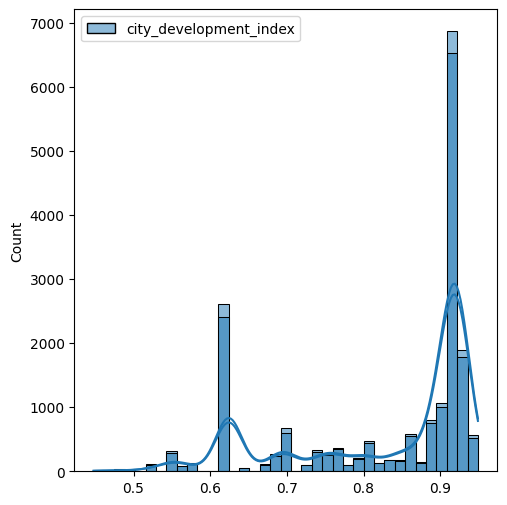

In [99]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df[['city_development_index']], kde=True, color='blue')

sns.histplot(df_new[['city_development_index']], kde=True, color='red')

In [100]:
df['education_level'].value_counts().isnull()

education_level
Graduate          False
Masters           False
High School       False
Phd               False
Primary School    False
Name: count, dtype: bool

In [110]:
## For categotical data

df_new = df['education_level'].dropna().reset_index(drop=True)
df_new

0              Graduate
1              Graduate
2              Graduate
3              Graduate
4               Masters
              ...      
18693          Graduate
18694          Graduate
18695          Graduate
18696       High School
18697    Primary School
Name: education_level, Length: 18698, dtype: str

In [111]:
temp = pd.concat([df['education_level'].value_counts() / len(df), df_new.value_counts() / len(df_new)], axis=1, keys=['Original', 'After CCA'])
temp

,Original,After CCA
education_level,,
Graduate,0.605387,0.620280
Masters,0.227633,0.233234
High School,0.105282,0.107872
Phd,0.021610,0.022141
Primary School,0.016077,0.016472


In [ ]:
temp = pd.concat([
    df['education_level'].value_counts() / len(df), 
    df_new[''].value_counts() / len(df_new)
], axis=1, keys=['Original', 'After CCA'])
temp

,Original,After CCA
Graduate,0.605387,NaN
Masters,0.227633,NaN
High School,0.105282,NaN
Phd,0.021610,NaN
Primary School,0.016077,NaN
...,...,...
"(0.6890000000000001, Full time course, 2.0, 60.0)",NaN,0.000057
"(0.878, no_enrollment, 14.0, 42.0)",NaN,0.000057
"(0.92, no_enrollment, 14.0, 52.0)",NaN,0.000057
"(0.802, no_enrollment, 0.0, 97.0)",NaN,0.000057


## KNN Imputer

Knn imputer is a method of imputation that uses the K-nearest neighbors algorithm to fill in missing values in a dataset. It works by finding the K nearest neighbors of a data point with missing values and using the average (for numerical features) or the most frequent value (for categorical features) of those neighbors to impute the missing value.

Nan_euledeon Distances

sklearn.metrics.pairwise.nan_euclidean_distances(X, Y=None, *, squared=False, missing_values=nan, copy=True)[source]
Calculate the euclidean distances in the presence of missing values.

Compute the euclidean distance between each pair of samples in X and Y, where Y=X is assumed if Y=None. When calculating the distance between a pair of samples, this formulation ignores feature coordinates with a missing value in either sample and scales up the weight of the remaining coordinates:

dist(x,y) = sqrt(weight * sq. distance from present coordinates)
where:

weight = Total # of coordinates / # of present coordinates
For example, the distance between [3, na, na, 6] and [1, na, 4, 5] is:

 
$$dist = \sqrt{(4/2 * ((3-1)^2 + (6-5)^2))} = sqrt(8)$$

Advantages of KNN Imputer:

1. More accurate imputation.
2. More no of calculatingtions than mean or median imputation.
3. Production issue where you have to provide the imputer all the training data and test data both to fit and transform. So that it can impute the missing values in production / user data based on the training data.Like in KNN.

In [127]:
from sklearn.impute import KNNImputer , SimpleImputer
from sklearn.metrics.pairwise import nan_euclidean_distances

from sklearn.metrics import accuracy_score , r2_score

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split , cross_val_score

In [117]:
df = pd.read_csv('./datasets/Titanic-Dataset.csv' , usecols=['Age', 'Pclass', 'Fare', 'Survived'])

In [118]:
X_train , X_test , y_train , y_test = train_test_split(df.drop('Survived', axis=1), df['Survived'], test_size=0.2, random_state=88)

In [135]:
# Defining the Class

kni = KNNImputer(n_neighbors=5,metric='nan_euclidean',weights='distance')

In [136]:
# Applying the imputer on the training data

X_train = kni.fit_transform(X_train)
X_test = kni.transform(X_test)

pd.DataFrame(X_train , columns=['Pclass', 'Age', 'Fare'])

,Pclass,Age,Fare
0,3.0,34.2,7.7500
1,3.0,34.2,7.7500
2,3.0,15.2,25.4667
3,2.0,18.0,73.5000
4,3.0,19.0,0.0000
...,...,...,...
707,3.0,16.0,8.0500
708,3.0,34.2,7.7500
709,3.0,45.0,14.4542
710,3.0,17.0,7.1250


In [137]:
lr = LogisticRegression()

lr.fit(X_train , y_train)

lr.predict(X_test)

np.mean(cross_val_score(lr, X_train, y_train, cv=10))

np.float64(0.6981220657276995)

In [138]:
accuracy_score(y_test, lr.predict(X_test))
r2_score(y_test, lr.predict(X_test))

-0.23380204025365314

## Multivariate Imputation by Chained Equations (MICE)

Assumption for MICE:
1. Will work in MAR (Missing at Random) and MCAR (Missing Completely at Random) scenarios, but not in MNAR (Missing Not at Random) scenarios.


# Outliers
Outliers are data points that differ significantly from other observations in the dataset. They can be caused by measurement errors, data entry errors, or they may represent true variability in the data. 

Ways to Handle Outliers:
1. **Removing Outliers**: This involves identifying and removing outliers from the dataset.
2. **Capping Outliers**: This involves replacing outliers with a specified value, such as the mean or median of the feature.
3. **Missing Value Imputation**: This involves treating outliers as missing values and using imputation techniques to fill in the missing values.

How to detect outliers?
1. **Z-score method**: This method identifies outliers by calculating the z-score for each data point and flagging those with a z-score greater than a certain threshold (commonly 3 or -3) as outliers.
2. **IQR method**: This method identifies outliers by calculating the interquartile range (IQR) for the data and flagging those that fall below Q1 - 1.5*IQR or above Q3 + 1.5*IQR as outliers.
3. **Percentile method**: This method identifies outliers by calculating the percentiles of the data and flagging those that fall below a certain percentile (e.g., 1st percentile) or above a certain percentile (e.g., 99th percentile) as outliers.

### Z-score method

Assumption for Z-score method:
1. The data is normally distributed across the feature.

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [30]:
cgpa = np.random.randint(3, 8, 100)
placement = np.round(np.random.uniform(3, 21, 100), 1)
placed = np.random.choice([0, 1], size=100)

df = pd.DataFrame({'cgpa': cgpa, 'placement': placement, 'placed': placed})
df.head()

,cgpa,placement,placed
0,7,8.6,1
1,7,9.4,0
2,4,17.8,1
3,5,3.5,1
4,7,12.3,0


In [38]:
new_outliers = pd.DataFrame({
    'cgpa': [0.5, 1.5, 9.99, 10.0],
    'placement': [2, 15, 30, 50],
    'placed': [0, 0, 1, 1]
})

df = pd.concat([df, new_outliers], ignore_index=True)

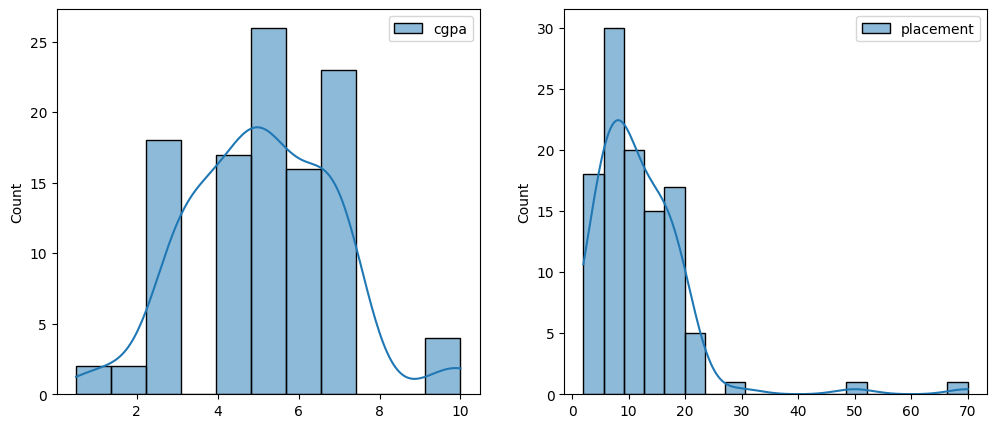

In [39]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[['cgpa']], kde=True, color='blue')

plt.subplot(1, 2, 2)
sns.histplot(df[['placement']], kde=True, color='orange')
plt.show()

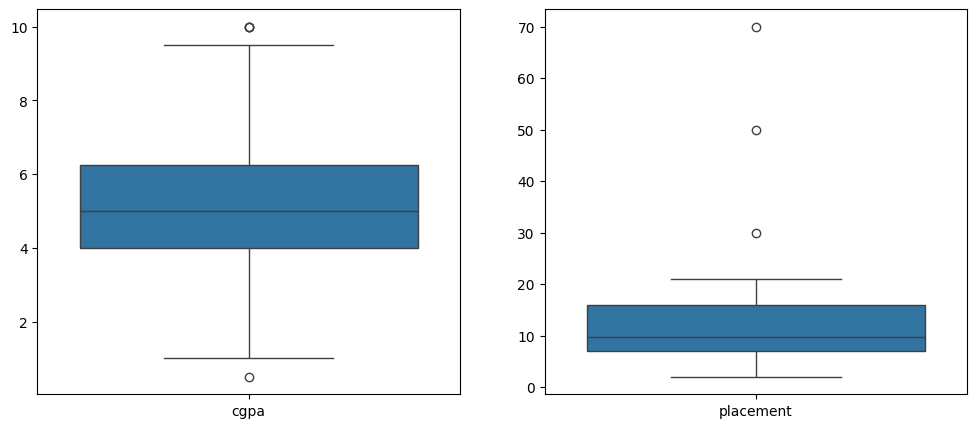

In [40]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(df[['cgpa']])

plt.subplot(1, 2, 2)
sns.boxplot(df[['placement']])
plt.show()

In [41]:
## We will apply Z-score in cgpa colum as it is having Normal distribution.

print('Mean of cgpa column is: ', df['cgpa'].mean())
print('Standard deviation of cgpa column is: ', df['cgpa'].std())



Mean of cgpa column is:  5.120277777777778
Standard deviation of cgpa column is:  1.8120512764986636


In [42]:
## Finding Boundaries for cgpa column
print('Higher Bound:', df[['cgpa']].mean() + 3 * df[['cgpa']].std())
print('Lower Bound:', df[['cgpa']].mean() - 3 * df[['cgpa']].std())

Higher Bound: cgpa    10.556432
dtype: float64
Lower Bound: cgpa   -0.315876
dtype: float64


In [43]:
df[(df['cgpa'] > 9.95) | (df['cgpa'] < 0.25)]

,cgpa,placement,placed
103,10.00,10.0,1
106,9.99,30.0,1
107,10.00,50.0,1


In [44]:
## Trimming

new_df = df[(df['cgpa'] <= 9.95) & (df['cgpa'] >= 0.25)]
new_df.head()

,cgpa,placement,placed
0,7.0,8.6,1
1,7.0,9.4,0
2,4.0,17.8,1
3,5.0,3.5,1
4,7.0,12.3,0


In [45]:
## Z_score for cgpa column

df['cgpa_zscore'] = stats.zscore(df['cgpa'])

new_df = df[(df['cgpa_zscore'] <= 3) & (df['cgpa_zscore'] >= -3)]
new_df.head()

,cgpa,placement,placed,cgpa_zscore
0,7.0,8.6,1,1.042181
1,7.0,9.4,0,1.042181
2,4.0,17.8,1,-0.621120
3,5.0,3.5,1,-0.066686
4,7.0,12.3,0,1.042181


## Outlier Detection using IQR method

Assumption for IQR method:
1. The data is not normally distributed and may contain outliers, as the IQR method is robust to outliers and does not assume any specific distribution for the data.

In [47]:
## Outlier Detection using IQR method
df['placement'].skew()

np.float64(3.5777921470073575)

<Axes: >

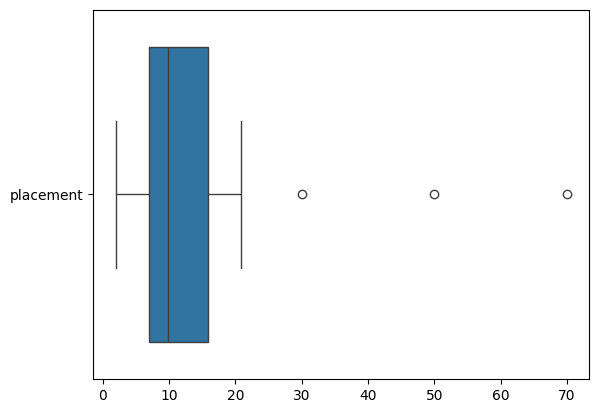

In [50]:
sns.boxplot(df[['placement']],orient='h')

In [51]:
percentile25 = np.quantile(df['placement'], 0.25)
percentile75 = np.quantile(df['placement'], 0.75)
iqr = percentile75 - percentile25
iqr

np.float64(8.900000000000002)

In [53]:
df['placement'].describe()

count    108.000000
mean      11.887963
std        8.753485
min        2.000000
25%        7.025000
50%        9.800000
75%       15.925000
max       70.000000
Name: placement, dtype: float64

In [54]:
upper_bound = percentile75 + 1.5 * iqr
lower_bound = percentile25 - 1.5 * iqr

In [57]:
new_df = df[(df['placement'] <= upper_bound) & (df['placement'] >= lower_bound)]
new_df.head()

,cgpa,placement,placed,cgpa_zscore
0,7.0,8.6,1,1.042181
1,7.0,9.4,0,1.042181
2,4.0,17.8,1,-0.621120
3,5.0,3.5,1,-0.066686
4,7.0,12.3,0,1.042181


## Percentile method

In [58]:
upperlimit = df['placement'].quantile(0.99)
lowerlimit = df['placement'].quantile(0.01)

print('Upper limit is: ', upperlimit)
print('Lower limit is: ', lowerlimit)

Upper limit is:  48.59999999999985
Lower limit is:  2.0700000000000003


# Feature Construction

In [60]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.linear_model import LogisticRegression

import seaborn as sns

In [62]:
df = pd.read_csv('./datasets/Titanic-Dataset.csv' , usecols=['Age', 'Pclass', 'SibSp','Parch', 'Survived'])
df.head()

,Survived,Pclass,Age,SibSp,Parch
0,0,3,22.0,1,0
1,1,1,38.0,1,0
2,1,3,26.0,0,0
3,1,1,35.0,1,0
4,0,3,35.0,0,0


In [63]:
X_train , X_test , y_train , y_test = train_test_split(df.drop('Survived', axis=1), df['Survived'], test_size=0.2, random_state=88)

In [70]:
X_train.dropna(inplace=True)
X_test.dropna(inplace=True)

X_train.isnull().sum()

Pclass    0
Age       0
SibSp     0
Parch     0
dtype: int64

In [73]:
lr = LogisticRegression()

# Align target indices with rows kept after dropna in X_train/X_test
y_train_aligned = y_train.loc[X_train.index]
y_test_aligned = y_test.loc[X_test.index]

lr.fit(X_train, y_train_aligned)

np.mean(cross_val_score(lr, X_train, y_train_aligned, cv=10, scoring='accuracy'))

np.float64(0.6889411027568922)

In [74]:
## Applying feature Construction

X_train['Family_Size'] = X_train['SibSp'] + X_train['Parch'] + 1

In [76]:
def myFunc(num):
    if num == 1:
        return 0
    elif num > 1 and num <= 4:
        return 1
    else:
        return 2

In [ ]:
X_train['Family_Size']

385    1
302    1
394    3
187    1
472    4
      ..
865    1
574    1
362    2
433    1
288    1
Name: Family_Size, Length: 569, dtype: int64

In [ ]:
from sklearn.preprocessing import FunctionTransformer

tnf1 = FunctionTransformer(myFunc)

X_train['Family_Size_Category'] = tnf1.fit_transform(X_train['Family_Size'])
X_train.head()

AttributeError: 'Series' object has no attribute 'reshape'